# 01 · Data exploration: Kinyarwanda part of BRIGHTER

This notebook looks at the dataset before any modelling: where it comes from, a duplication
problem in the official release, how the six emotions are distributed, and what kinds of text
it contains. The cleaning itself happens in `src/data.py`; this notebook calls it and inspects
the result.

**Dataset:** BRIGHTER (Muhammad et al., 2025), the multi-label emotion dataset released for
SemEval-2025 Task 11, Track A. Kinyarwanda config `kin`, licence CC-BY-4.0, labelled by native speakers.
Each text gets 0/1 for each of **anger, disgust, fear, joy, sadness, surprise**; several can be 1 at once, or none.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import EMOTIONS, PROCESSED_DIR, RAW_DIR
from src.data import download_if_missing, normalize

# Chart style: light surface, recessive grid, text in neutral ink (never the series colour)
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#898781",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "text.color": "#0b0b0b", "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110})
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]  # validated categorical order
pd.set_option("display.max_colwidth", 120)

## 1. The raw release and its duplicates

In [2]:
download_if_missing()
raw = {s: pd.read_parquet(RAW_DIR / f"{s}.parquet") for s in ("train", "dev", "test")}
pd.DataFrame({s: {"rows": len(d), "unique texts": d["text"].nunique()} for s, d in raw.items()}).T

,rows,unique texts
train,2451,2451
dev,814,407
test,2462,1231


Dev and test have exactly **half** as many unique texts as rows. Each text appears twice:
once with a Track A id and once with a Track C id (Track C is the cross-lingual track),
with identical labels. Scoring both copies would count every test text twice.

In [3]:
dup = raw["test"][raw["test"]["text"] == raw["test"]["text"].iloc[0]]
dup[["id", "text", *EMOTIONS]]

,id,text,anger,disgust,fear,joy,sadness,surprise
0,kin_test_track_a_00001,@<username> tom nawe ko numva ukwirakwiza ibihuha wagiye usoma ##url##,1,0,0,0,0,0
1847,kin_test_track_c_00617,@<username> tom nawe ko numva ukwirakwiza ibihuha wagiye usoma ##url##,1,0,0,0,0,0


In [4]:
for s in ("dev", "test"):
    d = raw[s]
    conflicting = (d.groupby("text")[EMOTIONS].nunique() > 1).any(axis=1).sum()
    print(f"{s}: copies per text = {d['text'].value_counts().unique()}, copies with different labels = {conflicting}")

dev: copies per text = [2], copies with different labels = 0
test: copies per text = [2], copies with different labels = 0


## 2. Clean splits used for every experiment
`python -m src.data` normalises the text, drops the copies and writes `data/processed/`.

In [5]:
splits = {s: pd.read_csv(PROCESSED_DIR / f"{s}.csv") for s in ("train", "dev", "test")}
print("train/dev overlap:", len(set(splits["train"].text) & set(splits["dev"].text)),
      "| train/test overlap:", len(set(splits["train"].text) & set(splits["test"].text)))
pd.DataFrame({s: {"texts": len(d)} for s, d in splits.items()}).T

train/dev overlap: 0 | train/test overlap: 0


,texts
train,2451
dev,407
test,1231


**Normalisation** (`src/data.py: normalize`): typographic apostrophes are unified
(Kinyarwanda writes elided vowels as *n'abandi*, *y'imyaka*), anonymised `@<username>` and `##url##`
placeholders become `@user` / `URL`, and `#` is dropped from hashtags. Emojis and punctuation are
**kept**, because they carry emotion.

In [6]:
for t in splits["train"]["text"].sample(4, random_state=3):
    print("raw  :", t[:110]); print("clean:", normalize(t)[:110]); print()

raw  : @<username> afite ubuzima nk'abandi bose ntiyahamagarira abantu ku bwambura abandi nagende aragaceza muzunga
clean: @user afite ubuzima nk'abandi bose ntiyahamagarira abantu ku bwambura abandi nagende aragaceza muzunga

raw  : @<username> wo gatukure inda wee urikumva iyo skoo yateye yabyibye
clean: @user wo gatukure inda wee urikumva iyo skoo yateye yabyibye

raw  : @<username> @<username> slayboo ngo ubwo murasabiriza ariko buriya kurisha innyo nkuruyuki siko kabi ra cg kub
clean: @user @user slayboo ngo ubwo murasabiriza ariko buriya kurisha innyo nkuruyuki siko kabi ra cg kuba indaya ush

raw  : ubu ari gushaka inzira za gatanya kuko atumva ko yakomezanya nawe.
clean: ubu ari gushaka inzira za gatanya kuko atumva ko yakomezanya nawe.



## 3. How often each emotion occurs

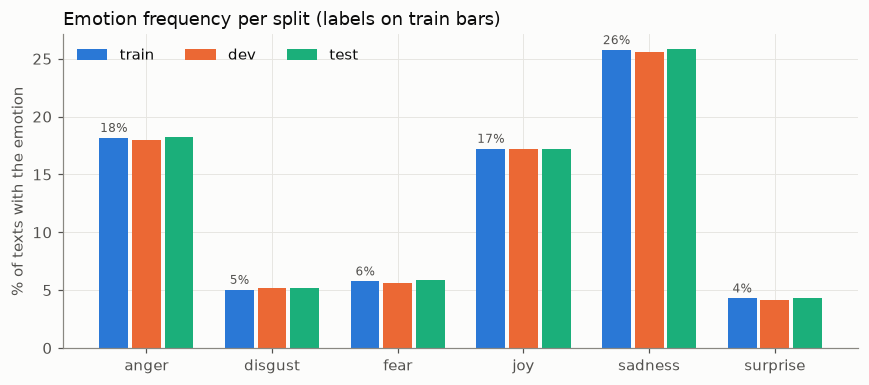

,train,dev,test
anger,18.2,17.9,18.3
disgust,5.0,5.2,5.2
fear,5.8,5.7,5.8
joy,17.2,17.2,17.2
sadness,25.7,25.6,25.8
surprise,4.3,4.2,4.3


In [7]:
share = pd.DataFrame({s: d[EMOTIONS].mean() * 100 for s, d in splits.items()})
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(EMOTIONS)); w = 0.26
for k, s in enumerate(share.columns):
    bars = ax.bar(x + (k - 1) * w, share[s], w - 0.03, color=SERIES[k], label=s)
ax.bar_label(ax.containers[0], fmt="%.0f%%", fontsize=8, color="#52514e", padding=2)
ax.set_xticks(x, EMOTIONS); ax.set_ylabel("% of texts with the emotion")
ax.set_title("Emotion frequency per split (labels on train bars)", loc="left")
ax.legend(frameon=False, ncol=3)
plt.tight_layout(); plt.savefig("results/figures/eda_emotion_frequency.png", dpi=150); plt.show()
share.round(1)

- Strong **imbalance**: sadness is in about a quarter of texts, surprise in 4%. This is why macro-F1
  (every emotion weighs the same) is the main metric, and why per-emotion thresholds are tuned.
- The three splits have almost the same distribution, so dev is a fair guide to test.

In [8]:
n = pd.DataFrame({s: d[EMOTIONS].sum(axis=1).value_counts().sort_index() for s, d in splits.items()}).fillna(0).astype(int)
n.index.name = "emotions per text"; n

,train,dev,test
emotions per text,,,
0,708,118,354
1,1620,270,811
2,122,19,65
3,1,0,1


29% of texts have **no** emotion, so "none" is a real answer, and about 5% have two or more. A single-label (softmax) classifier could not represent this, which is why every model uses one sigmoid per emotion.

### Which emotions appear together?

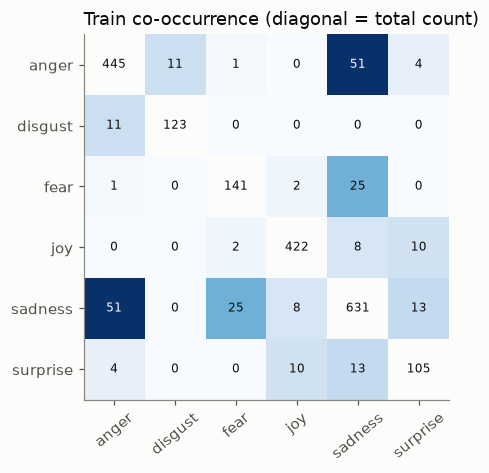

In [9]:
X = splits["train"][EMOTIONS]
co = X.T @ X
fig, ax = plt.subplots(figsize=(5.2, 4.4))
off = co.values.astype(float).copy(); np.fill_diagonal(off, np.nan)
im = ax.imshow(off, cmap="Blues")
for i in range(6):
    for j in range(6):
        ax.text(j, i, co.values[i, j], ha="center", va="center", fontsize=8,
                color="white" if i != j and off[i, j] > np.nanmax(off) * 0.6 else "#0b0b0b")
ax.set_xticks(range(6), EMOTIONS, rotation=40); ax.set_yticks(range(6), EMOTIONS); ax.grid(False)
ax.set_title("Train co-occurrence (diagonal = total count)", loc="left")
plt.tight_layout(); plt.savefig("results/figures/eda_cooccurrence.png", dpi=150); plt.show()

**Sadness + anger** (51) and **sadness + fear** (25) are the common pairs, the same pairs the models later confuse.

## 4. What the texts look like

In [10]:
tr = splits["train"].copy()
tr["words"] = tr["clean_text"].str.split().str.len()
tr["tweet"] = tr["text"].str.contains("@<username>")
tr["has_url"] = tr["text"].str.contains("##url##")
print(f"mean {tr.words.mean():.1f} words, 95th percentile {tr.words.quantile(.95):.0f}, max {tr.words.max()}")
print(f"{tr.tweet.mean():.0%} contain an @mention (tweets), {tr.has_url.mean():.0%} a link")
rows = []
for e in EMOTIONS + ["none"]:
    m = tr[e] == 1 if e != "none" else tr[EMOTIONS].sum(axis=1) == 0
    rows.append({"emotion": e, "texts": int(m.sum()), "mean words": tr.loc[m, "words"].mean(),
                 "% tweets": tr.loc[m, "tweet"].mean() * 100})
profile = pd.DataFrame(rows).set_index("emotion").round(1); profile

mean 17.7 words, 95th percentile 33, max 63
31% contain an @mention (tweets), 13% a link


,texts,mean words,% tweets
emotion,,,
anger,445,15.9,56.0
disgust,123,7.2,0.8
fear,141,20.8,12.1
joy,422,18.8,42.9
sadness,631,20.4,15.2
surprise,105,18.8,10.5
none,708,17.1,34.6


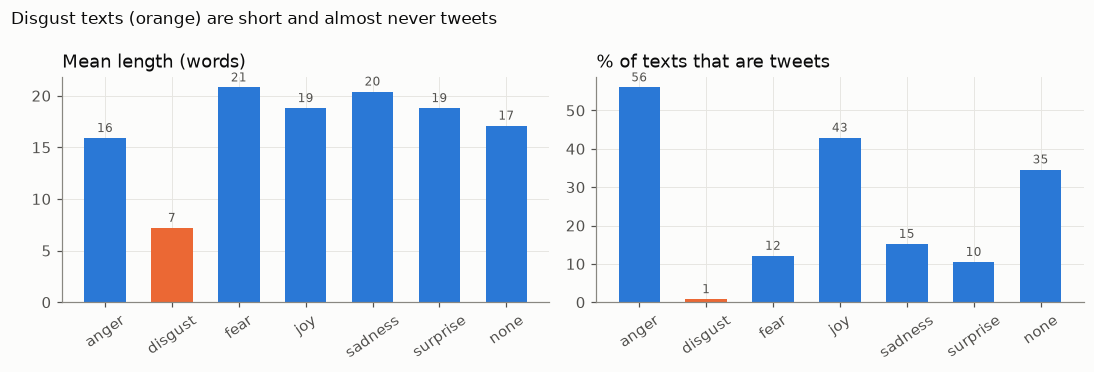

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, col, title in [(axes[0], "mean words", "Mean length (words)"), (axes[1], "% tweets", "% of texts that are tweets")]:
    colors = ["#eb6834" if e == "disgust" else "#2a78d6" for e in profile.index]
    b = ax.bar(profile.index, profile[col], color=colors, width=0.62)
    ax.bar_label(b, fmt="%.0f", fontsize=8, color="#52514e", padding=2)
    ax.set_title(title, loc="left"); ax.tick_params(axis="x", rotation=35)
fig.suptitle("Disgust texts (orange) are short and almost never tweets", x=0.01, ha="left", fontsize=11)
plt.tight_layout(); plt.savefig("results/figures/eda_text_profile.png", dpi=150); plt.show()

**A dataset artefact:** disgust texts average about 7 words against about 18 for the rest, and
almost none are tweets. They look like short written sentences about *physical* disgust (dirt,
smell, vomit). A model can recognise them from style and a handful of words, which is why every
model later scores well on disgust (F1 ≈ 0.85) despite it being rare. Anger is the most "tweet-like" emotion (about half are @replies).

### Length in sub-word tokens
Transformers do not see words but SentencePiece pieces. With `max_len = 128`, how many texts get cut?

In [12]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("Davlan/afro-xlmr-large")
rows = {}
for s, d in splits.items():
    n = d["clean_text"].map(lambda t: len(tok(t)["input_ids"]))
    rows[s] = {"mean tokens": round(n.mean(), 1), "max tokens": n.max(), "texts > 128 (truncated)": int((n > 128).sum()),
               "tokens per word": round((n - 2).sum() / d["clean_text"].str.split().str.len().sum(), 2)}
print(tok.tokenize("ndumva mfite agahinda kenshi uyu munsi"))
pd.DataFrame(rows).T

['▁', 'ndum', 'va', '▁m', 'fi', 'te', '▁aga', 'hin', 'da', '▁ken', 'shi', '▁', 'uyu', '▁mun', 'si']


,mean tokens,max tokens,texts > 128 (truncated),tokens per word
train,46.6,157.0,9.0,2.52
dev,47.3,130.0,1.0,2.54
test,47.1,177.0,7.0,2.52


About **2.5 pieces per Kinyarwanda word** (*agahinda* becomes *aga·hin·da*), and only 17 of 4,089 texts exceed 128 tokens; those lose their last few words.

## 5. Examples of each emotion (train)

In [13]:
for e in EMOTIONS:
    print(f"── {e}")
    single = tr[(tr[e] == 1) & (tr[EMOTIONS].sum(axis=1) == 1) & (tr.words.between(6, 22))]
    for t in single["clean_text"].sample(2, random_state=1):
        print("   ", t)

── anger
    @user jya uvuga ibyo uzi rero ntugapfe kuvuga ibyo ubonye byose!
    @user @user wintera ishyari dore cya gikoko nahinduye job ngisubiza banyiracyo 😭😭😭
── disgust
    none se ndaterura umwana witumye mju myenda?
    birria imigage gusa niyo mpamvu basura nk'isatura.
── fear
    uyu munsi nabeshye landlord ikinyoma gikomeye ariko umenya birankoraho. foolsday
    kugeza ubu umuryango w'abibumbye n'ibindi bihugu bivuga ko bihangayikishijwe n'umutekano wa perezida wahiritswe, mohamed bazoum, umaze ibyumweru birenga bibiri afungishijwe ijisho.
── joy
    iyo muganira ntatinya kukubwira ko yakijijwe ibintu bitandukanye birimo ibibi yakoraga uyu munsi atatinyuka nko kunywa urumogi ndetse no gusambana.
    @user uwo kurara tugenda, bazubake comptoire muri free zone twinywere twisanzuye tubyina.
── sadness
    ni iki kikubabaza ukumva wanakirasa kuri iyi mihanda? me: kwandika tweet ntubone na like n'imwe😓😓😓😓😓😓numva nswenyutse ndaq
    umukozi w'umujyi wa kigali yarenze ku byo abate

## Summary

| Finding | Consequence for modelling |
|---|---|
| Dev/test rows duplicated (Track A + C ids) | Deduplicated: 2,451 / 407 / 1,231 texts |
| Heavy imbalance (sadness 26% … surprise 4%) | Macro-F1 as main metric; class weights; per-emotion thresholds |
| 29% no emotion, 5% multi-emotion | Six independent sigmoid outputs, not a softmax |
| Short texts (~18 words ≈ 47 sub-word tokens) | `max_len` 128 covers 99.6% of texts; 17 long ones are truncated |
| ~31% tweets with mentions, slang, emojis | Emojis and punctuation kept in normalisation |
| Disgust = short, non-tweet, distinctive vocabulary | Expect high disgust F1 for a dataset reason; discussed in error analysis |